# Advanced layer types -- Image Classification

## 0. Import packages and modules

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import pathlib

import sklearn
import torch
from torch import nn

from torchinfo import summary
#import torchmetrics

print(sklearn.__version__)
print(torch.__version__)

1.6.1
2.8.0


In [2]:
# print GPU info

print(f"CUDA available: {torch.cuda.is_available()}")

print(f"Num GPUs Available: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.get_device_name(device)}: temp: {torch.cuda.temeperature(device)} °C, power draw: {torch.cuda.power_draw()} mW, clock rate: {torch.cuda.clock_rate}")
else:
    device = torch.device("cpu")

CUDA available: False
Num GPUs Available: 0


## 1. Formulate / Outline the problem: Image classification

In [3]:
DATA_FOLDER = pathlib.Path(f"{os.environ['HOME']}/Downloads/DollarStreet10") # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

## 2. Identify inputs and outputs

In [4]:
train_images.shape

(878, 64, 64, 3)

In [5]:
train_images.min(), train_images.max()

(np.int32(0), np.int32(255))

In [6]:
train_labels.shape

(878,)

In [7]:
train_labels.min(), train_labels.max()

(np.int64(0), np.int64(9))

## 3. Prepare data

In [8]:
class DollarStreetDataset(torch.utils.data.Dataset):
    def __init__(self, root, train=True):
        prefix = "test"
        if train == True:
            prefix = "train"
        self.images = np.load(root / f'{prefix}_images.npy') / 255.
        self.labels = np.load(root / f'{prefix}_labels.npy')
        
    def __getitem__(self, idx):
        x = torch.permute(torch.tensor(self.images[idx], dtype=torch.float), (2, 0, 1))
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y
        
    def __len__(self):
        return self.images.shape[0]

train_ds = DollarStreetDataset(root=DATA_FOLDER, train=True)
val_ds = DollarStreetDataset(root=DATA_FOLDER, train=False)

## 4. Build a pretrained model

In [9]:
class DollarStreetModelSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(50*60*60, 10),
        )
    def forward(self, x):
        return self.s(x)

model = DollarStreetModelSmall()

In [10]:
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DollarStreetModelSmall                   [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 50, 60, 60]           22,550
│    └─ReLU: 2-4                         [1, 50, 60, 60]           --
│    └─Flatten: 2-5                      [1, 180000]               --
│    └─Linear: 2-6                       [1, 10]                   1,800,010
Total params: 1,823,960
Trainable params: 1,823,960
Non-trainable params: 0
Total mult-adds (M): 88.36
Input size (MB): 0.05
Forward/backward pass size (MB): 2.98
Params size (MB): 7.30
Estimated Total Size (MB): 10.32

In [11]:
class DollarStreetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(14*14*50, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

model = DollarStreetModel()
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DollarStreetModel                        [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─MaxPool2d: 2-3                    [1, 50, 31, 31]           --
│    └─Conv2d: 2-4                       [1, 50, 29, 29]           22,550
│    └─ReLU: 2-5                         [1, 50, 29, 29]           --
│    └─MaxPool2d: 2-6                    [1, 50, 14, 14]           --
│    └─Flatten: 2-7                      [1, 9800]                 --
│    └─Linear: 2-8                       [1, 50]                   490,050
│    └─ReLU: 2-9                         [1, 50]                   --
│    └─Linear: 2-10                      [1, 10]                   510
Total params: 514,510
Trainable params: 514,510
Non-trainable params: 0


## 5. Choose a loss function and optimizer

In [12]:
optim = torch.optim.Adam(model.parameters(), lr=0.001)
crit = torch.nn.CrossEntropyLoss()

## 6. Train the model

In [13]:
def train(dl, model, loss_fn, optimizer, device=torch.device("cuda:0")):
    model = model.to(device)
    model.train()
    avg_loss, correct = 0., 0.
    for step, (x, y) in (enumerate(pbar:=tqdm(dl))):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        avg_loss += loss.item()
        pbar.set_description(f"Loss: {(loss.item()):>7f}")
        loss.backward()
        optimizer.step()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    avg_loss /= len(dl)
    correct /= len(dl.dataset)
    return avg_loss, correct

def test(dl, model, loss_fn, device=torch.device("cuda:0")):
    model = model.to(device)
    model.eval()
    loss, correct = 0., 0.
    with torch.no_grad():
        for step, (x, y) in enumerate(dl):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    loss /= len(dl)
    correct /= (len(dl.dataset))
    print(f"Test accuracy: {(100 * correct):>0.1f}%, Avg loss: {loss:>8f}")
    return loss, correct


In [14]:
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=1, shuffle=False)
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
for epoch in range(30):
    print(f"Epoch {epoch}:")
    loss, accuracy = train(train_dl, model, crit, optim, device=device)
    val_loss, val_accuracy = test(train_dl, model, crit, device=device)

    for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
        history[k].append(v)

Epoch 0:


Loss: 2.288237: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00,  9.60it/s]


Test accuracy: 12.4%, Avg loss: 2.280777
Epoch 1:


Loss: 2.206337: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 10.36it/s]


Test accuracy: 19.0%, Avg loss: 2.221532
Epoch 2:


...

Test accuracy: 98.7%, Avg loss: 0.099628
Epoch 28:


Loss: 0.174744: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 10.31it/s]


Test accuracy: 98.4%, Avg loss: 0.111431
Epoch 29:


Loss: 0.052863: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 10.22it/s]


Test accuracy: 97.9%, Avg loss: 0.113536


## 7. Perform a Prediction/Classification

## 8. Measure performance

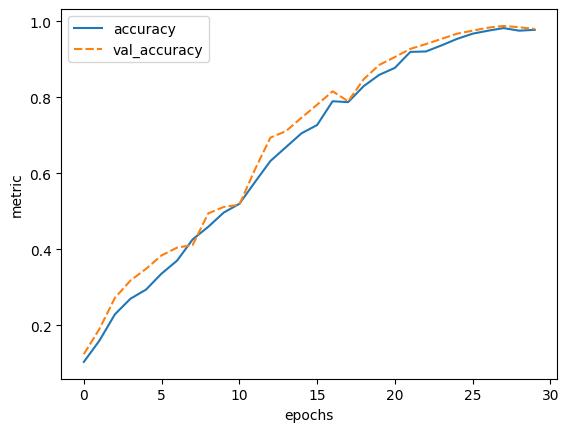

In [15]:
def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history(dict): dictionary containing metrics over the course of training
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")

plot_history(history, ['accuracy', 'val_accuracy'])

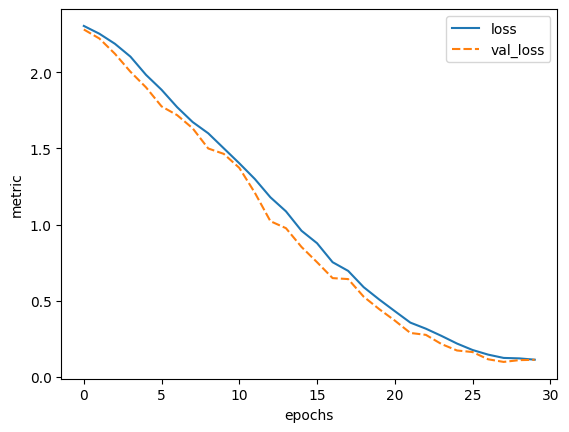

In [16]:
plot_history(history, ['loss', 'val_loss'])

**Comparison with a network with only dense layers**

In [17]:
class DenseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Flatten(),
            nn.Linear(12288, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        return self.s(x)

dense_model = DenseModel()
summary(dense_model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
DenseModel                               [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 12288]                --
│    └─Linear: 2-2                       [1, 50]                   614,450
│    └─ReLU: 2-3                         [1, 50]                   --
│    └─Linear: 2-4                       [1, 50]                   2,550
│    └─ReLU: 2-5                         [1, 50]                   --
│    └─Linear: 2-6                       [1, 10]                   510
Total params: 617,510
Trainable params: 617,510
Non-trainable params: 0
Total mult-adds (M): 0.62
Input size (MB): 0.05
Forward/backward pass size (MB): 0.00
Params size (MB): 2.47
Estimated Total Size (MB): 2.52

Epoch 0:


Loss: 2.289588: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 173.93it/s]


Test accuracy: 14.4%, Avg loss: 2.274528
Epoch 1:


Loss: 2.145981: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 233.79it/s]


Test accuracy: 15.6%, Avg loss: 2.299533
Epoch 2:


...

Test accuracy: 42.5%, Avg loss: 1.699541
Epoch 28:


Loss: 1.668498: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 290.64it/s]


Test accuracy: 43.5%, Avg loss: 1.671274
Epoch 29:


Loss: 1.792183: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 287.52it/s]


Test accuracy: 42.0%, Avg loss: 1.658216


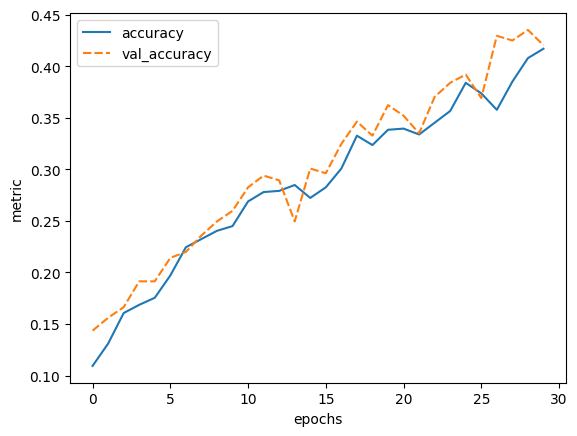

In [18]:
optim = torch.optim.Adam(dense_model.parameters(), lr=0.001)
crit = torch.nn.CrossEntropyLoss()
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
for epoch in range(30):
    print(f"Epoch {epoch}:")
    loss, accuracy = train(train_dl, dense_model, crit, optim, device=device)
    val_loss, val_accuracy = test(train_dl, dense_model, crit, device=device)

    for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
        history[k].append(v)

plot_history(history, ['accuracy', 'val_accuracy'])

## 9. Refine the model

In [19]:
class ModelDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.s = nn.Sequential(
            nn.Conv2d(3, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.8),  # This is new!
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.8),  # This is new!
            nn.Conv2d(50, 50, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.8),  # This is new!
            nn.Flatten(),
            nn.Linear(1800, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )
    def forward(self, x):
        self.s(x)

model_dropout = ModelDropout()
summary(model_dropout, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
ModelDropout                             --                        --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 50, 62, 62]           1,400
│    └─ReLU: 2-2                         [1, 50, 62, 62]           --
│    └─MaxPool2d: 2-3                    [1, 50, 31, 31]           --
│    └─Dropout: 2-4                      [1, 50, 31, 31]           --
│    └─Conv2d: 2-5                       [1, 50, 29, 29]           22,550
│    └─ReLU: 2-6                         [1, 50, 29, 29]           --
│    └─MaxPool2d: 2-7                    [1, 50, 14, 14]           --
│    └─Dropout: 2-8                      [1, 50, 14, 14]           --
│    └─Conv2d: 2-9                       [1, 50, 12, 12]           22,550
│    └─ReLU: 2-10                        [1, 50, 12, 12]           --
│    └─MaxPool2d: 2-11                   [1, 50, 6, 6]             --
│   

In [20]:
optim = torch.optim.Adam(model_dropout.parameters(), lr=1e-4)
crit = torch.nn.CrossEntropyLoss()
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
for epoch in range(20):
    print(f"Epoch {epoch}:")
    loss, accuracy = train(train_dl, dense_model, crit, optim, device)
    val_loss, val_accuracy = test(train_dl, dense_model, crit, device)

    for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
        history[k].append(v)

Epoch 0:


Loss: 1.647899: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 217.73it/s]


Test accuracy: 42.0%, Avg loss: 1.659810
Epoch 1:


Loss: 1.532104: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 293.55it/s]


Test accuracy: 42.0%, Avg loss: 1.663058
Epoch 2:


...

Test accuracy: 42.0%, Avg loss: 1.662364
Epoch 18:


Loss: 1.620340: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 342.65it/s]


Test accuracy: 42.0%, Avg loss: 1.665414
Epoch 19:


Loss: 1.681939: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 353.30it/s]


Test accuracy: 42.0%, Avg loss: 1.665677


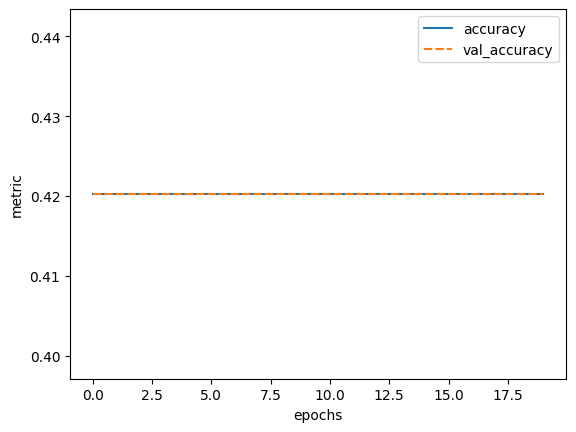

In [21]:
plot_history(history, ['accuracy', 'val_accuracy'])

In [22]:
class HPModel(nn.Module):
    def __init__(self, dropout_rate, n_layers):
        super().__init__()
        self.in_layer = nn.Sequential(nn.Conv2d(3, 50, 3), nn.ReLU(), nn.MaxPool2d(2))
        self.hidden_layers = nn.Sequential(*[nn.Sequential(nn.Conv2d(50, 50, 3), nn.ReLU(), nn.MaxPool2d(2)) for n in range(n_layers-1)])
        n_features_after_flatten = 64
        for n in range(n_layers):
            n_features_after_flatten = (n_features_after_flatten - 2)//2
        n_features_after_flatten ** 2 * 50
        self.head = nn.Sequential(nn.Dropout(dropout_rate), nn.Flatten(), nn.Linear(n_features_after_flatten , 50), nn.ReLU(), nn.Linear(50, 10))
    def forward(self, x):
        x = self.in_layer(x)
        x = self.hidden_layers(x)
        x = self.head(x)
        return x

**NOTE**: here we need to install keras_tuner. In LUMI, it comes preinstalled. Otherwise run the following inside a Jupyter cell: 

```
!python3 -m pip install keras_tuner
```

In [23]:
n_layers_grid = [1, 2]
dropout_rate_grid = np.linspace(.2, .8, 3)

best = None
best_loss = float("inf")
best_model = None
histories = {}
trial = 0



for n_layers in n_layers_grid:
    for p in dropout_rate_grid:
        model = HPModel(p, n_layers)
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        crit = torch.nn.CrossEntropyLoss()
        histories[n_layers, p] = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
        for epoch in range(20):
            loss, accuracy = train(train_dl, dense_model, crit, optim, device)
            val_loss, val_accuracy = test(train_dl, dense_model, crit, device)

            if val_loss < best_loss:
                best_loss = val_loss
                best = (n_layers, p)
                best_model = model

            for k, v in [("loss", loss), ("val_loss", val_loss), ("accuracy", accuracy), ("val_accuracy", val_accuracy)]:
                histories[n_layers, p][k].append(v)
        print(f"trial {trial}: params: {n_layers}, {p}; best: {best_loss} at {best}")
        trial += 1


Loss: 1.867557: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 339.00it/s]


Test accuracy: 42.0%, Avg loss: 1.662785


Loss: 1.847926: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 308.43it/s]


Test accuracy: 42.0%, Avg loss: 1.659304


Loss: 1.777110: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 321.51it/s]


...

Test accuracy: 42.0%, Avg loss: 1.663098


Loss: 1.720419: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 310.00it/s]


Test accuracy: 42.0%, Avg loss: 1.663382


Loss: 1.705518: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 306.82it/s]


Test accuracy: 42.0%, Avg loss: 1.664491
trial 5: params: 2, 0.8; best: 1.6564100214413233 at (1, np.float64(0.5))


In [24]:
print(f"best val loss: {best_loss} at {best}")
print(trial)

best val loss: 1.6564100214413233 at (1, np.float64(0.5))
6


## 10. Share model

In [26]:
torch.save(best_model.state_dict(), "image_classifcation.pth")